# Simple ML: Predict CCD Accuracy and Response Time from Evoked (-2, 0)
This notebook extracts per-subject evoked responses for the `contrastChangeDetection` task with epoch window [-2, 0] s, builds simple features, and fits basic regression models to predict participants' `ccd_accuracy` (ACC) and `ccd_response_time` (RES).

## load data

In [ ]:
# Imports & logging
from pathlib import Path
import numpy as np
import os
from mne import grand_average
sys.path.append(os.path.abspath("/mount/NAS-workspace-portal/eeg2025-Vistec/"))

from eegkit.utils.system.logging_utils import configure_logging, silence_console_logs
from eegkit.models.subject_model import EEGSubjectModel
from eegkit.controller.eeg_controller import EEGController
from eegkit.models.dtos import TaskDTO, SubjectFilterDTO
from eegkit.models.dtos import EvokedParamsDTO
from eegkit.utils.channels import prepare_channels

configure_logging('INFO')
silence_console_logs('WARNING')

### Setup

In [2]:
DATA_DIR = Path(os.getenv("DATA_DIR") or os.getenv("EEG_DATA_DIR") or "")
if not DATA_DIR or not DATA_DIR.exists():
    raise FileNotFoundError("Set DATA_DIR to your BIDS root containing cmi_bids_R*/ directories.")

subject_model = EEGSubjectModel(DATA_DIR)
controller = EEGController(subject_model)

In [3]:
# Parameters: subjects, channels, and evoked window
N_SUBJECTS = 500  # use first N subjects
CHANNELS = "69-76,81-83,88,89"  # explicit posterior channels

# Evoked feature extraction params ([-2, 0] s)
params = EvokedParamsDTO(
    tmin=-2.0,
    tmax=0.0,
    stimulus=[None],
    channels=CHANNELS,
    notch=None,
    uv_min=None,
    uv_max=None,
    clean_flatline_sec=None,
    clean_hf_noise_sd_max=None,
    clean_corr_min=None,
    clean_asr_max_std=None,
    clean_power_min_sd=None,
    clean_power_max_sd=None,
    clean_max_outbound_pct=None,
    clean_window_sec=None,
    spatial_colors=True,
    average_line=True,
)
print(f"Subjects: {N_SUBJECTS}, Channels: {CHANNELS}")

Subjects: 500, Channels: 69-76,81-83,88,89


## Load

In [ ]:
group_dto = SubjectFilterDTO(task='contrastChangeDetection', subject_limit=N_SUBJECTS)
all_task_dtos = subject_model.get_filter_subjects_dto(group_dto)

seen = set()
selected_dtos = []
for dto in all_task_dtos:
    if dto.subject in seen:
        continue
    seen.add(dto.subject)
    selected_dtos.append(dto)
    if len(selected_dtos) >= N_SUBJECTS:
        break

selected_subjects = [d.subject for d in selected_dtos]
print(f"Selected subjects ({len(selected_subjects)}):", selected_subjects[:10])

Selected subjects (500): ['sub-NDARAA948VFH', 'sub-NDARAB678VYW', 'sub-NDARAB793GL3', 'sub-NDARAC904DMU', 'sub-NDARAD774HAZ', 'sub-NDARAE828CML', 'sub-NDARAG143ARJ', 'sub-NDARAG340ERT', 'sub-NDARAG788YV9', 'sub-NDARAK770XEW']


In [ ]:
# Build one evoked per subject by averaging across ALL CCD runs
evk_list, ok_subjects = [], []
task_name = 'contrastChangeDetection'

for subj in selected_subjects:
    subj_tasks = subject_model.list_tasks(subj)
    runs = [r for (t, r) in subj_tasks if t == task_name] or [None]

    evks = []
    for run in runs:
        dto = TaskDTO(subject=subj, task=task_name, run=run)
        evk = controller.get_evoked(dto, params)
        if evk is None:
            continue
        evks.append(prepare_channels(evk, params))

    if not evks:
        continue

    evk_avg = evks[0] if len(evks) == 1 else grand_average(evks)
    evk_list.append(evk_avg)
    ok_subjects.append(subj)

df_meta = subject_model.get_subjects_metadata(ok_subjects, columns=['ccd_accuracy','ccd_response_time'])
df_meta = df_meta.set_index('participant_id').loc[ok_subjects]
y_df = df_meta[['ccd_accuracy','ccd_response_time']].copy()
y = y_df.astype(float).values

## Model

### ML

In [ ]:
import numpy as np
import time
def evoked_list_to_X(evoked_list, scale_to_uv=True):
    X = []
    for evk in evoked_list:
        # evk.data: (n_channels, n_times)
        data = evk.data
        if scale_to_uv:
            data = data * 1e6  # optional: V -> µV (pure scaling)
        X.append(data.reshape(-1))  # flatten to 1D
    return np.stack(X, axis=0)  # (n_samples, n_features)

X = evoked_list_to_X(evk_list)

In [19]:
save_path = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/data/X_evoked_{N_SUBJECTS}_{time.time()}.npy")
np.save(save_path, X)

print("Saved to", save_path)

Saved to /mount/NAS-workspace-portal/eeg2025-Vistec/models/data/X_evoked_500_1771166523.7729328.npy


In [20]:
save_path = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/data/Y_evoked_{N_SUBJECTS}_{time.time()}.npy")
np.save(save_path, y)

print("Saved to", save_path)

Saved to /mount/NAS-workspace-portal/eeg2025-Vistec/models/data/Y_evoked_500_1771166884.1613965.npy


In [7]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 2613)
y shape: (500, 2)


In [8]:
y = np.asarray(y)
y_acc = y[:, 0] 
y_rt  = y[:, 1]

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
 
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# corr_acc, corr_rt = [], []
# mae_acc, mae_rt = [], []

# for train_idx, test_idx in kf.split(X):
#     model = make_pipeline(StandardScaler(), PCA(n_components=50), Ridge(alpha=1.0))
#     model.fit(X[train_idx], y[train_idx])
#     y_pred = model.predict(X[test_idx])
#     y_true = y[test_idx]

#     # correlation per target
#     c0 = np.corrcoef(y_pred[:,0], y_true[:,0])[0,1]
#     c1 = np.corrcoef(y_pred[:,1], y_true[:,1])[0,1]
#     corr_acc.append(c0)
#     corr_rt.append(c1)

#     mae_acc.append(mean_absolute_error(y_true[:,0], y_pred[:,0]))
#     mae_rt.append(mean_absolute_error(y_true[:,1], y_pred[:,1]))

# print("ACC corr mean:", np.nanmean(corr_acc), "MAE mean:", np.mean(mae_acc))
# print("RT  corr mean:", np.nanmean(corr_rt),  "MAE mean:", np.mean(mae_rt))


ACC corr mean: -0.034561672294641355 MAE mean: 21.070146881517637
RT  corr mean: -0.06750979968877893 MAE mean: 0.3042940342495773


In [10]:
components_list = [5, 10, 20, 30, 50, 80]

best_model = None
best_corr_rt = -np.inf

for n_comp in components_list:
    corr_rt = []

    for train_idx, test_idx in kf.split(X):
        model = make_pipeline(
            StandardScaler(),
            PCA(n_components=n_comp),
            Ridge(alpha=1.0)
        )

        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])
        y_true = y[test_idx]

        c = np.corrcoef(y_pred[:,1], y_true[:,1])[0,1]
        corr_rt.append(c)

    mean_corr = np.nanmean(corr_rt)
    print(f"PCA {n_comp} → RT corr:", mean_corr)
    
    if mean_corr > best_corr_rt:
        best_corr_rt = mean_corr
        best_model = make_pipeline(
            StandardScaler(),
            PCA(n_components=n_comp),
            Ridge(alpha=1.0)
        )
        best_model.fit(X, y)

print(f"\nBest: PCA {best_model.named_steps['pca'].n_components} with RT corr {best_corr_rt:.4f}")

PCA 5 → RT corr: 0.029993640523477895
PCA 10 → RT corr: -0.07700218237288012
PCA 20 → RT corr: 0.016507492311801847
PCA 30 → RT corr: -0.0427928409603629
PCA 50 → RT corr: -0.06978354754028625
PCA 80 → RT corr: 0.03436835037289813

Best: PCA 80 with RT corr 0.0344


In [11]:
y_pred = best_model.predict(X)

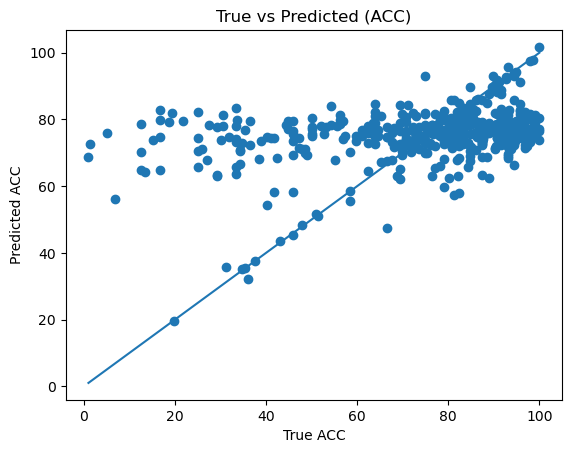

In [12]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(y[:,0], y_pred[:,0])
plt.xlabel("True ACC")
plt.ylabel("Predicted ACC")
plt.title("True vs Predicted (ACC)")
plt.plot([y[:,0].min(), y[:,0].max()],
         [y[:,0].min(), y[:,0].max()])
plt.show()


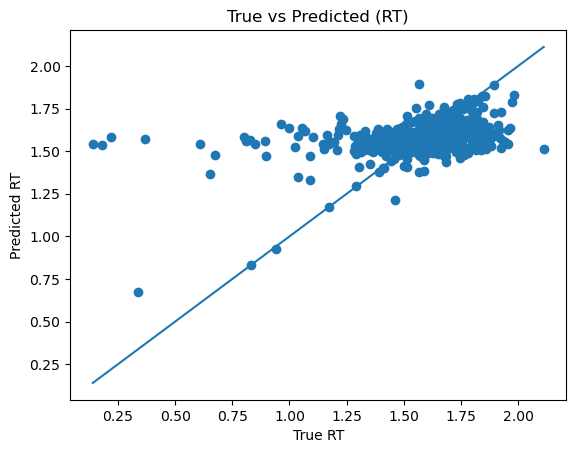

In [21]:
plt.figure()
plt.scatter(y[:,1], y_pred[:,1])
plt.xlabel("True RT")
plt.ylabel("Predicted RT")
plt.title("True vs Predicted (RT)")
plt.plot([y[:,1].min(), y[:,1].max()],
         [y[:,1].min(), y[:,1].max()])
plt.show()

In [17]:
import joblib
import time
model_path = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/ml/evoked_model_{N_SUBJECTS}_{time.time()}.pkl")
joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}")

Model saved to /mount/NAS-workspace-portal/eeg2025-Vistec/models/ml/evoked_model_500_1771166304.2371216.pkl


### Deep Learing